# Вариант 513–5. Разбор партии бутылок по углу продольного шва

**Исходные данные.** `описание_задания.pdf` — общая схема работы (наборы `D1`
и `D2`, требования к обоснованию, список из 16 критериев),
`problems.pdf` — описание эксперимента и постановка задачи.
**Данные.** `problem_2_sample_data/`: `example_H0.csv` и `example_H1.csv`
(исходы известны заранее) и `sample_01.csv … sample_10.csv` (применение схемы).

Решение построено по пунктам задания: 1 — описание эксперимента,
2 — формулировка `H0` и `H1`, 3 — выбор критерия и обоснование его условий на `D1`,
4 — выбор уровня значимости, 5 — применение критерия к `D2` и выводы.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

plt.rcParams.update(
    {"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3}
)

DATA = Path("/Users/leyla_iz/Desktop/wtf/practice/513-5/problem_2_sample_data")
H0_FILE, H1_FILE = "example_H0.csv", "example_H1.csv"
SAMPLE_FILES = [f"sample_{i:02d}.csv" for i in range(1, 11)]


def load(name):
    # читает один столбец x (угол шва в градусах) из csv
    return np.loadtxt(DATA / name, skiprows=1)


D1 = {H0_FILE: load(H0_FILE), H1_FILE: load(H1_FILE)}
D2 = {f: load(f) for f in SAMPLE_FILES}
ALL = {**D1, **D2}

print("Набор D1 (исход известен):", {k: len(v) for k, v in D1.items()})
print("Набор D2 (применение критерия):", {k: len(v) for k, v in D2.items()})
print(f"Объём выборок: от {min(len(v) for v in ALL.values())} до "
      f"{max(len(v) for v in ALL.values())} бутылок")

Набор D1 (исход известен): {'example_H0.csv': 111, 'example_H1.csv': 129}
Набор D2 (применение критерия): {'sample_01.csv': 134, 'sample_02.csv': 111, 'sample_03.csv': 148, 'sample_04.csv': 123, 'sample_05.csv': 142, 'sample_06.csv': 100, 'sample_07.csv': 136, 'sample_08.csv': 140, 'sample_09.csv': 110, 'sample_10.csv': 102}
Объём выборок: от 100 до 148 бутылок


## 1. Описание эксперимента и цель статистического анализа

На линии розлива бутылки идут из накопителя по транспортёру на этикетировочную
машину. У стеклянной бутылки есть продольный шов от формы, и этикетка ложится
именно на этот шов — тогда она морщится и уходит в брак. Видеодатчик перед
захватом измеряет угол между швом и осью транспортёра (отсчёт по часовой стрелке
от направления движения ленты, значения в $[0, 360)$ — полный оборот замыкается
сам на себя). В выборку идёт бутылка за бутылкой.

Бутылки ничем не ориентированы, их разворачивает толчками соседок и неровностями
ленты. **Если механика систематически не доворачивает бутылки, никакое положение
шва не выделено: углы встречаются одинаково часто по всему обороту, то есть
распределение равномерное.** Если же бутылку что-то доворачивает (пружинная
направляющая, рифление ленты, скошенный отбойник у ворота), то бутылки приезжают
на захват преимущественно в одном положении, шов раз за разом оказывается под
этикеткой — и идёт брак.

**Цель анализа:** для каждой линии (выборки) установить, есть ли выделенное
положение шва, то есть виновата ли механика. Ответ «да» означает
«подрегулировать направляющие и отбойник» (полчаса работы механика),
ответ «нет» — «искать причину в клее и температуре в цехе».

## 2. Формулировка гипотез

Обозначим $X$ — угол шва, $F(x)=P(X\le x)$ — его функцию распределения
на $[0,360)$, $n$ — объём выборки (число бутылок подряд).

$$H_0:\quad F(x)=\frac{x}{360},\quad 0\le x<360
\qquad\text{(равномерное распределение)}$$

$$H_1:\quad F(x)\ne \frac{x}{360}\ \text{на множестве положительной длины}
\qquad\text{(избыток углов в некотором секторе)}$$

Смысл в терминах задачи:

* $H_0$ — **механика не при чём**: шов попадает под этикетку случайно, брак
  вызван клеем, температурой, подачей и т. п.;
* $H_1$ — **механика при чём**: есть сектор углов, в который бутылки
  систематически доворачиваются; именно этот сектор надо править.

Гипотеза $H_0$ **полностью задаёт распределение** (никакие параметры
не оцениваются) — это важно для выбора критерия: p-значение получается точным.
Отдельно отметим: $\mathbb{E}X=180$ — это *следствие* $H_0$, но не равносильное
условие, поэтому проверка среднего не является проверкой равномерности (п. 3.3).

In [2]:
# Описательные статистики всех выборок + ориентиры для равномерного распределения
UNIF_MEAN, UNIF_SD = 180.0, 360 / np.sqrt(12)      # 180 и 103.923

rows = []
for name, x in ALL.items():
    rows.append({
        "файл": name, "n": len(x), "среднее": x.mean(), "медиана": np.median(x),
        "стандартное отклонение": x.std(ddof=1),
        "IQR": np.subtract(*np.percentile(x, [75, 25])),
        "min": x.min(), "max": x.max(),
        "асимметрия": stats.skew(x), "эксцесс": stats.kurtosis(x),
    })
desc = pd.DataFrame(rows).set_index("файл").round(2)
print(f"Если X ~ U[0,360):  E[X] = {UNIF_MEAN},  sd(X) = 360/sqrt(12) = {UNIF_SD:.2f}, "
      f"медиана = 180, асимметрия = 0")
desc

Если X ~ U[0,360):  E[X] = 180.0,  sd(X) = 360/sqrt(12) = 103.92, медиана = 180, асимметрия = 0


,n,среднее,медиана,стандартное отклонение,IQR,min,max,асимметрия,эксцесс
файл,,,,,,,,,
example_H0.csv,111,183.75,183.17,100.82,175.88,5.16,355.70,-0.06,-1.27
example_H1.csv,129,141.13,110.23,90.52,89.62,4.34,356.77,0.86,-0.26
sample_01.csv,134,164.24,116.88,99.83,155.33,4.53,356.86,0.41,-1.13
sample_02.csv,111,180.11,180.72,100.71,160.38,0.87,358.64,0.14,-1.05
sample_03.csv,148,189.11,191.26,103.81,174.09,4.81,358.67,-0.11,-1.23
sample_04.csv,123,185.42,183.66,104.06,183.43,1.10,349.84,-0.20,-1.13
sample_05.csv,142,158.44,118.62,93.04,131.70,2.92,359.39,0.50,-0.72
sample_06.csv,100,151.42,116.52,81.06,102.59,0.47,359.03,0.75,-0.24
sample_07.csv,136,182.31,186.35,101.27,169.49,1.03,352.88,-0.09,-1.11


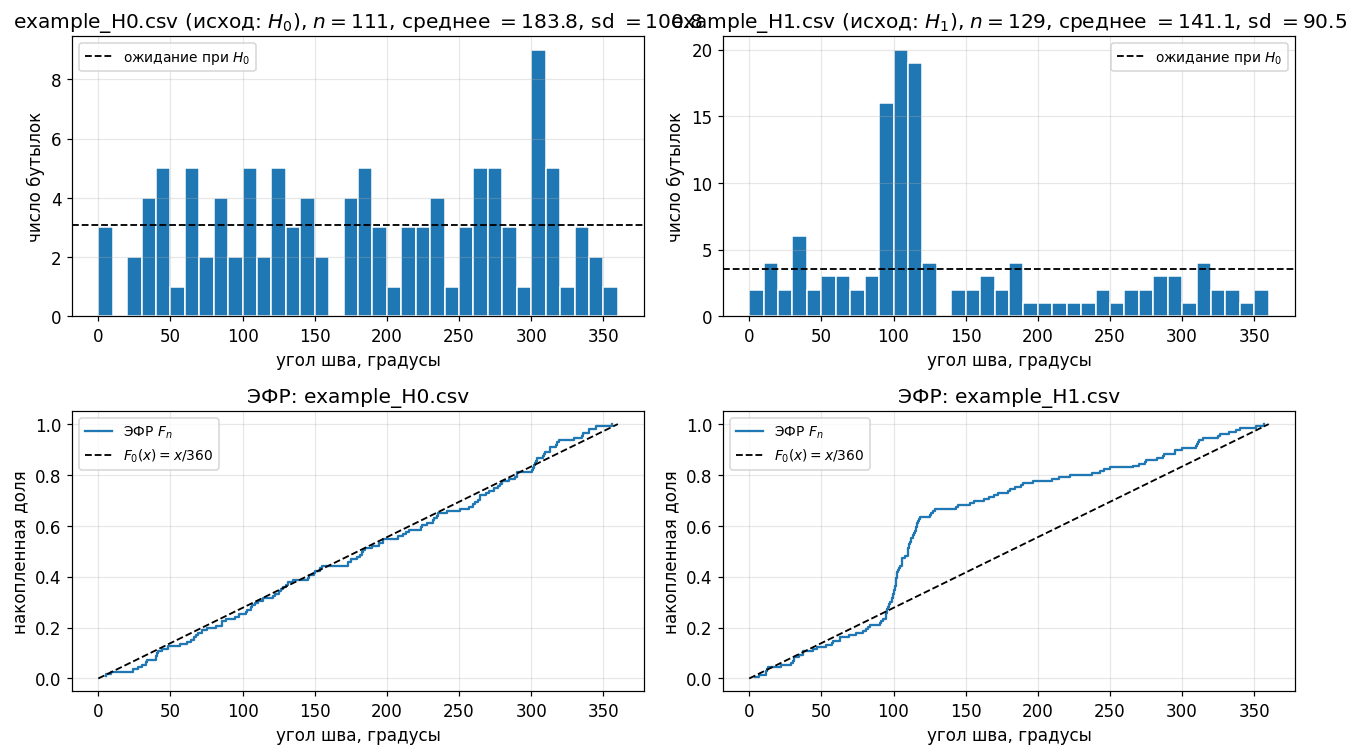

example_H0.csv: разброс равномерный, среднее 183.8 ≈ 180, sd 100.8 ≈ 103.9, асимметрия -0.06
example_H1.csv: избыток в секторе 90..120 градусов: 55 из 129 бутылок (43% при равномерном ожидании 8.3%)


In [3]:
# 1. Как выглядят данные набора D1
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (name, x) in zip(axes[0], D1.items()):
    ax.hist(x, bins=np.arange(0, 361, 10), color="tab:blue", edgecolor="w")
    ax.axhline(len(x) / 36, color="k", ls="--", lw=1.2, label="ожидание при $H_0$")
    ax.set_title(f"{name} (исход: {'$H_0$' if name == H0_FILE else '$H_1$'}), "
                 f"$n={len(x)}$, среднее $={x.mean():.1f}$, sd $={x.std(ddof=1):.1f}$")
    ax.set_xlabel("угол шва, градусы")
    ax.set_ylabel("число бутылок")
    ax.legend(fontsize=9)

for ax, (name, x) in zip(axes[1], D1.items()):
    xs = np.sort(x)
    ax.step(xs, np.arange(1, len(x) + 1) / len(x), where="post", color="tab:blue",
            label="ЭФР $F_n$")
    ax.plot([0, 360], [0, 1], "k--", lw=1.2, label="$F_0(x)=x/360$")
    ax.set_title(f"ЭФР: {name}")
    ax.set_xlabel("угол шва, градусы")
    ax.set_ylabel("накопленная доля")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

x0, x1 = D1[H0_FILE], D1[H1_FILE]
print(f"{H0_FILE}: разброс равномерный, среднее {x0.mean():.1f} ≈ 180, "
      f"sd {x0.std(ddof=1):.1f} ≈ {UNIF_SD:.1f}, асимметрия {stats.skew(x0):+.2f}")
print(f"{H1_FILE}: избыток в секторе 90..120 градусов: "
      f"{np.sum((x1 >= 90) & (x1 < 120))} из {len(x1)} бутылок "
      f"({100 * np.mean((x1 >= 90) & (x1 < 120)):.0f}% при равномерном ожидании 8.3%)")

## 3. Выбор критерия и обоснование его применимости

Наша $H_0$ — **одновыборочная** гипотеза о **согласии с полностью заданным
распределением** (равномерным), данные по каждой линии — **одна независимая
выборка непрерывных значений** (не два набора для сравнения и не парные
наблюдения). Отсюда отбор из предложенного списка:

| критерий | применим? | почему |
|---|---|---|
| №1, №3, №4 Стьюдента / Уэлча | нет | сравнение среднего с константой либо двух выборок; требует нормальности, которой нет (п. 3.2) |
| №2 Стьюдента для парных | нет | парных наблюдений нет |
| №5 Манна–Уитни, №7 Вилкоксона, №9 знаков | нет | нужны две выборки; распределения не связаны сдвигом (п. 3.2) |
| №6 Фишера | нет | сравнение дисперсий, а не распределений |
| №8 знаков о вероятности успеха | нет | бинарный признак, а у нас непрерывный угол |
| №10, №11, №15 Хи-квадрат | формально нет | предполагают **дискретные** данные, а данные непрерывны (п. 3.1) |
| №12 Шапиро–Уилк | вспомогательный | проверка нормальности — нужна, чтобы обосновать отказ от критериев Стьюдента |
| **№13 Колмогорова–Смирнова (согласия)** | **да** | согласие с заданным непрерывным распределением, одна выборка |
| №16 KS на две выборки | вспомогательный | пригодится для проверки непротиворечивости выводов (п. 5.2) |

Выбран **критерий согласия Колмогорова–Смирнова (№13)** с равномерным законом
$F_0(x)=x/360$. Распределение задано целиком и не содержит оцениваемых
параметров, поэтому его p-значение **точное**, а не асимптотическое, и оно
корректно при $n \approx 100$.

### 3.1. Природа данных: непрерывные, а не дискретные

Если данные дискретны, KS в исходном виде неприменим, а критерии Хи-квадрат
как раз потребовали бы дискретности. Проверим.

In [4]:
# 3.1. Проверка непрерывности: все значения различны, шага сетки нет
rows = []
for name, x in ALL.items():
    rows.append({
        "файл": name, "n": len(x), "различных значений": len(np.unique(x)),
        "доля близких к целым": np.mean(np.isclose(x, np.round(x))),
    })
cont = pd.DataFrame(rows).set_index("файл").round(3)
print("Во всех выборках число различных значений равно n -> повторов нет;")
print("доля значений, близких к целым (признак «датчик с шагом 1 градус»):",
      cont["доля близких к целым"].max())
cont

Во всех выборках число различных значений равно n -> повторов нет;
доля значений, близких к целым (признак «датчик с шагом 1 градус»): 0.015


,n,различных значений,доля близких к целым
файл,,,
example_H0.csv,111,111,0.000
example_H1.csv,129,129,0.008
sample_01.csv,134,134,0.007
sample_02.csv,111,111,0.000
sample_03.csv,148,148,0.014
sample_04.csv,123,123,0.000
sample_05.csv,142,142,0.000
sample_06.csv,100,100,0.010
sample_07.csv,136,136,0.015


In [5]:
# 3.2. Проверка нормальности (критерий №12) и допущения о сдвиге на данных D1
for name, x in D1.items():
    p = stats.shapiro(x).pvalue
    print(f"{name}: Шапиро–Уилк p = {p:.2e} -> нормальность "
          f"{'отвергается' if p < 0.05 else 'не отвергается'}")

x0, x1 = D1[H0_FILE], D1[H1_FILE]
print(f"\nДиапазоны: H0 = [{x0.min():.1f}, {x0.max():.1f}], "
      f"H1 = [{x1.min():.1f}, {x1.max():.1f}]")
print(f"Средние: {x0.mean():.1f} и {x1.mean():.1f}; медианы: "
      f"{np.median(x0):.1f} и {np.median(x1):.1f}")
print("-> распределения пересекаются и различаются по форме (избыток в одном "
      "секторе), а не сдвигом: ранговые критерии (№5, №7) к такой паре неприменимы.")
print("-> критерии Стьюдента/Уэлча формально неприменимы: гипотеза нормальности "
      "отвергнута, а проверять надо не среднее, а функцию распределения целиком.")

example_H0.csv: Шапиро–Уилк p = 2.38e-04 -> нормальность отвергается
example_H1.csv: Шапиро–Уилк p = 1.26e-08 -> нормальность отвергается

Диапазоны: H0 = [5.2, 355.7], H1 = [4.3, 356.8]
Средние: 183.8 и 141.1; медианы: 183.2 и 110.2
-> распределения пересекаются и различаются по форме (избыток в одном секторе), а не сдвигом: ранговые критерии (№5, №7) к такой паре неприменимы.
-> критерии Стьюдента/Уэлча формально неприменимы: гипотеза нормальности отвергнута, а проверять надо не среднее, а функцию распределения целиком.


### 3.3. Почему нельзя ограничиться критерием Стьюдента

$\mathbb{E}X=180$ — следствие $H_0$, но не эквивалентное условие: есть
распределения заведомо неравномерные, но с тем же средним. Проверим численно:
«равномерный фон + перегруженный сектор 165°…195°», то есть выделенное положение
ровно напротив оси транспортёра.

In [6]:
rng = np.random.default_rng(1)
B = 2000
p_ks, p_t = [], []
for _ in range(B):
    x = np.concatenate([rng.uniform(0, 360, 96), rng.uniform(165, 195, 34)])
    p_ks.append(stats.kstest(x, "uniform", args=(0, 360)).pvalue)
    p_t.append(stats.ttest_1samp(x, 180).pvalue)
p_ks, p_t = np.array(p_ks), np.array(p_t)
print(f"n = 130, {B} симуляций «фон + сектор 165..195°» (выделенное положение есть!):")
print(f"  KS (№13):       отвергает H0 в {100 * np.mean(p_ks < 0.10):.1f}% случаев, "
      f"медиана p = {np.median(p_ks):.2e}")
print(f"  Стьюдента (№1): отвергает H0 в {100 * np.mean(p_t < 0.10):.1f}% случаев, "
      f"медиана p = {np.median(p_t):.2f}  <- ровно уровень α, критерий бесполезен")
print("Вывод: проверка среднего может полностью промолчать при заведомо "
      "неравномерном распределении. Нужен критерий согласия с распределением.")

n = 130, 2000 симуляций «фон + сектор 165..195°» (выделенное положение есть!):
  KS (№13):       отвергает H0 в 99.9% случаев, медиана p = 3.69e-03
  Стьюдента (№1): отвергает H0 в 10.0% случаев, медиана p = 0.50  <- ровно уровень α, критерий бесполезен
Вывод: проверка среднего может полностью промолчать при заведомо неравномерном распределении. Нужен критерий согласия с распределением.


### 3.4. Калибровка выбранного критерия на наборе D1

Проверяем размер (не отвергает истинную $H_0$) и мощность (отвергает заведомо
ложную $H_0$).

In [7]:
def ks_uniform(x):
    # Критерий согласия Колмогорова–Смирнова (№13) с равномерным законом
    r = stats.kstest(x, "uniform", args=(0, 360), alternative="two-sided")
    return r.statistic, r.pvalue


print("Калибровка на D1 (порог alpha = 0.10):")
for name, x in D1.items():
    D, p = ks_uniform(x)
    print(f"  {name:16s} n={len(x):4d}  D = {D:.4f}  p = {p:.3e}  -> "
          f"{'ОТВЕРГНУТЬ H0' if p < 0.10 else 'не отвергать H0'}")

rng = np.random.default_rng(0)
print("\nРазмер критерия (20 000 равномерных выборок — H0 верна в точности):")
for n in (100, 120, 150):
    p = np.array([ks_uniform(rng.uniform(0, 360, n))[1] for _ in range(20000)])
    print(f"  n = {n:3d}: доля p < 0.10 = {np.mean(p < 0.10):.3f} (ожидается 0.100), "
          f"доля p < 0.05 = {np.mean(p < 0.05):.3f}, медиана p = {np.median(p):.3f}")

x0 = D1[H0_FILE]
p_bs = np.array([ks_uniform(rng.choice(x0, 120, replace=True))[1] for _ in range(20000)])
print(f"  бутстрэп из example_H0 при n = 120: доля p < 0.10 = {np.mean(p_bs < 0.10):.3f}"
      f" <- завышено: пересобранная выборка дискретна (опора из 111 значений), "
      f"а KS требует непрерывности (ср. п. 3.1)")

Калибровка на D1 (порог alpha = 0.10):
  example_H0.csv   n= 111  D = 0.0505  p = 9.264e-01  -> не отвергать H0
  example_H1.csv   n= 129  D = 0.3093  p = 1.853e-11  -> ОТВЕРГНУТЬ H0

Размер критерия (20 000 равномерных выборок — H0 верна в точности):


  n = 100: доля p < 0.10 = 0.101 (ожидается 0.100), доля p < 0.05 = 0.051, медиана p = 0.503


  n = 120: доля p < 0.10 = 0.102 (ожидается 0.100), доля p < 0.05 = 0.051, медиана p = 0.500


  n = 150: доля p < 0.10 = 0.099 (ожидается 0.100), доля p < 0.05 = 0.048, медиана p = 0.502


  бутстрэп из example_H0 при n = 120: доля p < 0.10 = 0.197 <- завышено: пересобранная выборка дискретна (опора из 111 значений), а KS требует непрерывности (ср. п. 3.1)


In [8]:
# Мощность на правдоподобной альтернативе, пересозданной из example_H1
rng = np.random.default_rng(2)
x1 = D1[H1_FILE]
print("Мощность (2000 выборок размера n, пересозданных из example_H1):")
for n in (100, 120, 150):
    p = np.array([ks_uniform(rng.choice(x1, n, replace=True))[1] for _ in range(2000)])
    print(f"  n = {n:3d}: доля p < 0.10 = {np.mean(p < 0.10):.3f}, "
          f"медиана p = {np.median(p):.2e}")
print("Мощность близка к 1 уже при n ~ 100: объёмы выборок D2 заведомо "
      "достаточны, чтобы такой дефект поймать.")

# 3.5. Почему всё-таки не Хи-квадрат с ячейками (№11)
for w in (20, 30, 45, 60):
    counts = np.histogram(D2["sample_01.csv"], bins=np.arange(0, 361, w))[0]
    print(f"  Хи-квадрат, ячейки по {w:2d} градусов: p = "
          f"{stats.chisquare(counts).pvalue:.2e}")
print("Результат зависит от произвольного выбора ширины ячейки, а сам критерий "
      "для непрерывных данных корректен лишь асимптотически.")

Мощность (2000 выборок размера n, пересозданных из example_H1):


  n = 100: доля p < 0.10 = 1.000, медиана p = 2.37e-09


  n = 120: доля p < 0.10 = 1.000, медиана p = 3.12e-11


  n = 150: доля p < 0.10 = 1.000, медиана p = 8.19e-14
Мощность близка к 1 уже при n ~ 100: объёмы выборок D2 заведомо достаточны, чтобы такой дефект поймать.
  Хи-квадрат, ячейки по 20 градусов: p = 4.03e-23
  Хи-квадрат, ячейки по 30 градусов: p = 2.66e-24
  Хи-квадрат, ячейки по 45 градусов: p = 1.48e-14
  Хи-квадрат, ячейки по 60 градусов: p = 2.87e-13
Результат зависит от произвольного выбора ширины ячейки, а сам критерий для непрерывных данных корректен лишь асимптотически.


### 3.6. Итог обоснования

Выбран **критерий согласия Колмогорова–Смирнова (№13)** с равномерным
распределением на $[0,360)$:

1. **Тип гипотезы** — одновыборочная, о согласии с полностью заданным
   распределением; параметры не оцениваются, поэтому p-значение точное.
2. **Природа выборки** — одна независимая непрерывная выборка на линию;
   непрерывность подтверждена в п. 3.1, что попутно делает **неприменимыми**
   критерии Хи-квадрат (№10, №11, №15), рассчитанные на дискретные данные.
3. **Условия применимости** — проверены на `D1`:
   * `example_H0` (заведомо $H_0$): $p = 0.93$ — истинная гипотеза не
     отвергается; на симуляциях размер совпадает с номиналом ($0.10$ при
     $\alpha=0.10$, $0.05$ при $\alpha=0.05$);
   * `example_H1` (заведомо $H_1$): $p = 1.8\cdot10^{-11}$, мощность $\approx 1$
     при $n \ge 100$ — нужное отклонение не пропускается;
   * нормальность отвергнута (Шапиро–Уилк), распределения не связаны сдвигом
     → критерии Стьюдента, Уэлча, Манна–Уитни, Вилкоксона неприменимы.

## 4. Выбор уровня значимости $\alpha$

Из вариантов $0.01$, $0.05$, $0.10$ выбираем **$\alpha = 0.10$** по соотношению
потерь из описания эксперимента:

* **Ошибка первого рода** (отвергли $H_0$, а механика ни при чём) — зря
  потраченные полчаса механика на санитарной остановке; прямо сказано, что
  **«лишняя регулировка ничего не испортит»**. Потери малы и обратимы.
* **Ошибка второго рода** ($H_0$ не отвергли, а перегруженный сектор есть) —
  механику не подрегулируют, и **месяц брака по этикетке обойдётся линии куда
  дороже**. Потери велики и накапливаются месяцами.

Потери несимметричны, поэтому нужно быть чувствительнее к пропуску дефекта,
чем к ложной тревоге: отсюда наибольший из предложенных уровней,
$\alpha = 0.10$. Уровень $\alpha$ не навязан «по умолчанию», а следует из
экспериментальных издержек — это и требует п. 4 задания.

Проверим устойчивость выводов: все $p$-значения в `D2` попадают либо в
$p \le 1.5\cdot10^{-4}$, либо в $p \ge 0.30$, поэтому ни $\alpha = 0.05$, ни
$\alpha = 0.01$ не меняют ни одного решения (проверка — в п. 5).

## 5. Применение критерия к набору D2

К каждой из десяти линий (выборок `sample_01 … sample_10`) применяется
одна и та же схема: критерий согласия Колмогорова–Смирнова с равномерным
законом на $[0,360)$, уровень $\alpha = 0.10$.

In [9]:
ALPHA = 0.10

rows = []
for name, x in D2.items():
    D, p = ks_uniform(x)
    rows.append({
        "файл": name, "n": len(x), "D": D, "p-value": p,
        "решение при 0.10": "ОТВЕРГНУТЬ H0" if p < ALPHA else "не отвергать H0",
        "при 0.05": "отвергнуть" if p < 0.05 else "не отвергать",
        "при 0.01": "отвергнуть" if p < 0.01 else "не отвергать",
    })
res = pd.DataFrame(rows).set_index("файл")
res["D"] = res["D"].round(4)
print(f"Критерий согласия Колмогорова–Смирнова, alpha = {ALPHA}")
res.assign(**{"p-value": res["p-value"].map(lambda v: f"{v:.2e}")})

Критерий согласия Колмогорова–Смирнова, alpha = 0.1


,n,D,p-value,решение при 0.10,при 0.05,при 0.01
файл,,,,,,
sample_01.csv,134,0.2157,5.96e-06,ОТВЕРГНУТЬ H0,отвергнуть,отвергнуть
sample_02.csv,111,0.0618,7.67e-01,не отвергать H0,не отвергать,не отвергать
sample_03.csv,148,0.0674,4.90e-01,не отвергать H0,не отвергать,не отвергать
sample_04.csv,123,0.0867,2.96e-01,не отвергать H0,не отвергать,не отвергать
sample_05.csv,142,0.1811,1.51e-04,ОТВЕРГНУТЬ H0,отвергнуть,отвергнуть
sample_06.csv,100,0.2267,5.36e-05,ОТВЕРГНУТЬ H0,отвергнуть,отвергнуть
sample_07.csv,136,0.0514,8.47e-01,не отвергать H0,не отвергать,не отвергать
sample_08.csv,140,0.0702,4.74e-01,не отвергать H0,не отвергать,не отвергать
sample_09.csv,110,0.2431,3.30e-06,ОТВЕРГНУТЬ H0,отвергнуть,отвергнуть


In [10]:
n_rej = (res["p-value"] < ALPHA).sum()
print(f"Отвергнуто H0: {n_rej} из {len(res)} линий; не отвергнуто: {len(res) - n_rej}")
print("Решения при alpha = 0.10, 0.05 и 0.01 совпадают во всех случаях "
      "(см. предыдущую таблицу) -> вывод устойчив к выбору уровня.")
p_rej = res.loc[res["решение при 0.10"] == "ОТВЕРГНУТЬ H0", "p-value"]
p_non = res.loc[res["решение при 0.10"] == "не отвергать H0", "p-value"]
print(f"\nПравило принятия решений: у отвергнутых p-value <= {p_rej.max():.1e}, "
      f"у неотвергнутых p-value >= {p_non.min():.2f} — разрыв в "
      f"{np.log10(p_non.min() / p_rej.max()):.1f} порядка, «серой зоны» нет.")

Отвергнуто H0: 5 из 10 линий; не отвергнуто: 5
Решения при alpha = 0.10, 0.05 и 0.01 совпадают во всех случаях (см. предыдущую таблицу) -> вывод устойчив к выбору уровня.

Правило принятия решений: у отвергнутых p-value <= 1.5e-04, у неотвергнутых p-value >= 0.30 — разрыв в 3.3 порядка, «серой зоны» нет.


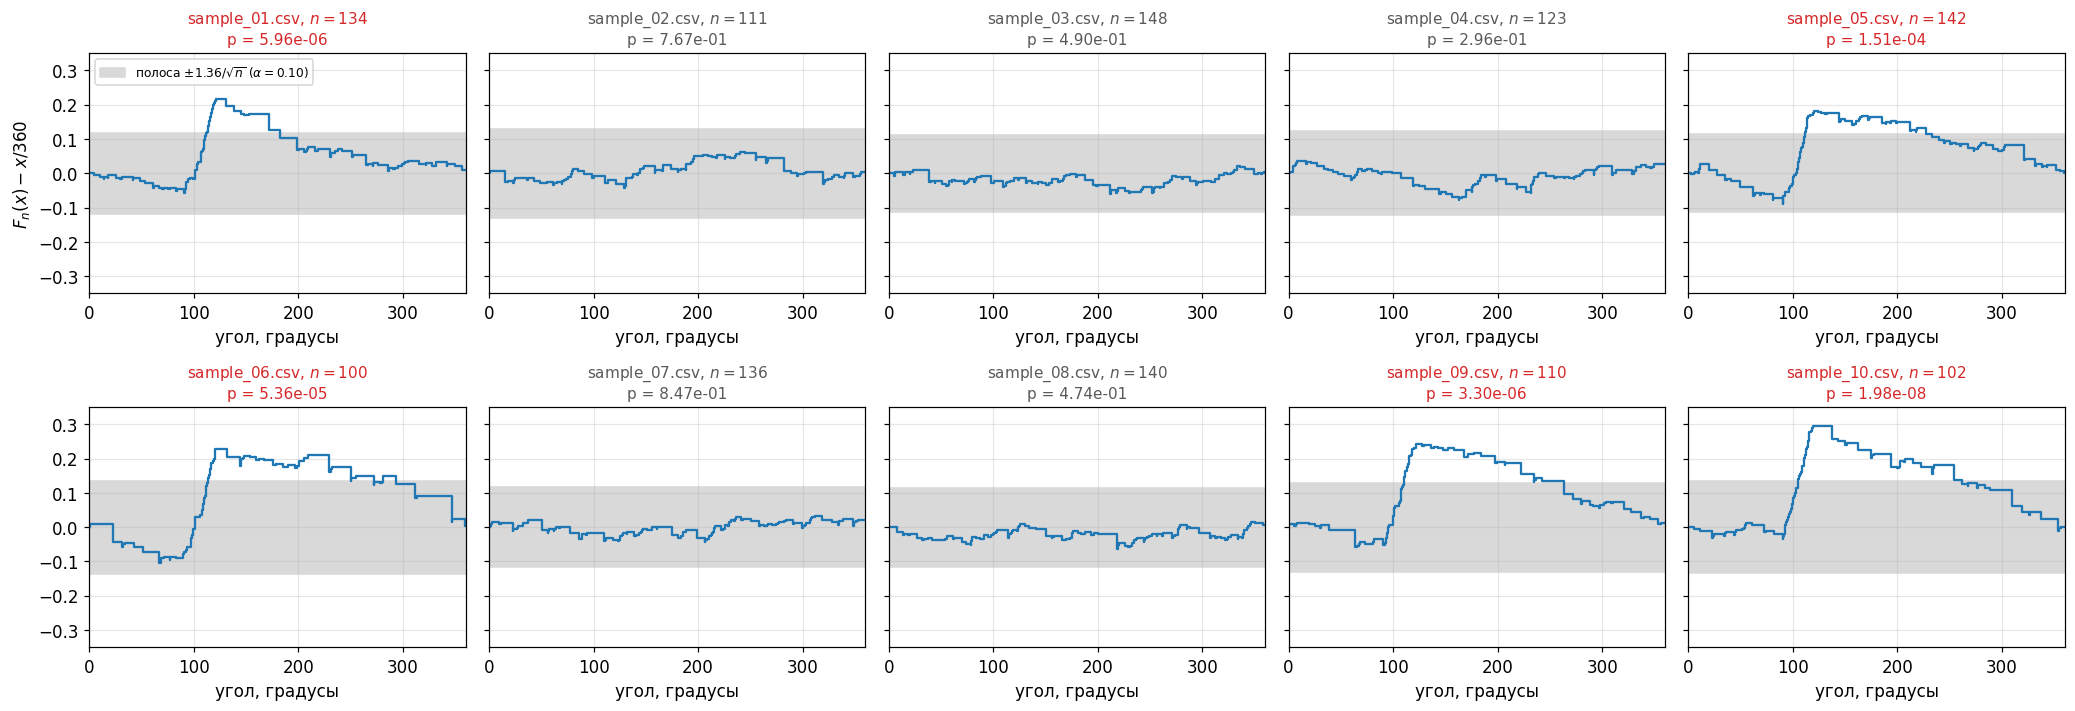

In [11]:
# 5.1. Графики по всем линиям D2: отклонение ЭФР от равномерной (с полосой alpha = 0.10)
fig, axes = plt.subplots(2, 5, figsize=(19, 6.6), sharey=True)
for ax, (name, x) in zip(axes.ravel(), D2.items()):
    xs = np.sort(x)
    n = len(x)
    emp = np.arange(1, n + 1) / n
    grid = np.concatenate([[0.0], xs, [360.0]])
    dev = np.concatenate([[0.0], emp - xs / 360, [1 - 1.0]])[:-1]
    band = stats.kstest(xs, "uniform", args=(0, 360)).pvalue, 1.36 / np.sqrt(n)
    ax.fill_between([0, 360], -band[1], band[1], color="0.85",
                    label=r"полоса $\pm 1.36/\sqrt{n}$ ($\alpha=0.10$)")
    ax.step(grid, np.concatenate([dev, dev[-1:]]), where="post", color="tab:blue")
    p = ks_uniform(x)[1]
    ax.set_title(f"{name}, $n={n}$\np = {p:.2e}", fontsize=10,
                 color="tab:red" if p < ALPHA else "0.35")
    ax.set_xlim(0, 360)
    ax.set_ylim(-0.35, 0.35)
    ax.set_xlabel("угол, градусы")
axes[0, 0].set_ylabel("$F_n(x) - x/360$")
axes[0, 0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

In [12]:
# 5.2. Однородность картины: отвергнутые и неотвергнутые линии различаются
rej = [f for f in D2 if ks_uniform(D2[f])[1] < ALPHA]
non = [f for f in D2 if ks_uniform(D2[f])[1] >= ALPHA]
print("Отвергнуты:", rej)
print("Не отвергнуты:", non)

# KS на две выборки (№16) как проверка непротиворечивости выводов:
# сравниваем объединённые группы по углам, приведённым к общей шкале 0..720
A = np.concatenate([D2[f] for f in rej])
B = np.concatenate([D2[f] for f in non])
AA = np.sort(np.concatenate([A, A + 360]) / 720)
BB = np.sort(np.concatenate([B, B + 360]) / 720)
r2 = stats.ks_2samp(AA, BB)
print(f"\nKS на две выборки (№16) между группами: D = {r2.statistic:.3f}, "
      f"p = {r2.pvalue:.2e}")
print(f"медиана углов: отвергнутые {np.median(A):.0f} градусов, "
      f"неотвергнутые {np.median(B):.0f} градусов")
print("-> две группы действительно разные: 5 линий требуют вмешательства механика, "
      "5 линий надо смотреть в сторону клея и температуры.")

Отвергнуты: ['sample_01.csv', 'sample_05.csv', 'sample_06.csv', 'sample_09.csv', 'sample_10.csv']
Не отвергнуты: ['sample_02.csv', 'sample_03.csv', 'sample_04.csv', 'sample_07.csv', 'sample_08.csv']

KS на две выборки (№16) между группами: D = 0.127, p = 3.19e-09
медиана углов: отвергнутые 115 градусов, неотвергнутые 185 градусов
-> две группы действительно разные: 5 линий требуют вмешательства механика, 5 линий надо смотреть в сторону клея и температуры.


In [13]:
# 5.3. Где именно доворачивает механика (описательно, после отклонения H0)
def hottest_sector(x, width=30, step=5):
    best = (0, -1)
    for s in np.arange(0, 360, step):
        e = s + width
        cnt = (np.sum((x >= s) & (x < e)) if e <= 360
               else np.sum((x >= s) | (x < e - 360)))
        if cnt > best[1]:
            best = (s, cnt)
    return best[0], best[1]


print("Оценка положения дефекта (последовательный поиск, 30-градусное окно):")
for name in [H1_FILE] + [f for f in SAMPLE_FILES if f in rej]:
    x = ALL[name]
    s, c = hottest_sector(x)
    share = c / len(x)
    print(f"  {name:16s} перегружен сектор {s:3.0f}..{(s + 30) % 360:3.0f} градусов: "
          f"{c:3d} из {len(x):3d} = {100 * share:4.0f}% "
          f"(равномерно ожидалось {100 * 30 / 360:.1f}%)")
print("\nОдин и тот же сектор у всех отклонённых линий и у эталона H1 -> "
      "регулировать нужно одну и ту же механику (отбойник/направляющую), "
      "а не десять разных узлов на разных линиях.")

Оценка положения дефекта (последовательный поиск, 30-градусное окно):
  example_H1.csv   перегружен сектор  90..120 градусов:  55 из 129 =   43% (равномерно ожидалось 8.3%)
  sample_01.csv    перегружен сектор  90..120 градусов:  48 из 134 =   36% (равномерно ожидалось 8.3%)
  sample_05.csv    перегружен сектор  90..120 градусов:  51 из 142 =   36% (равномерно ожидалось 8.3%)
  sample_06.csv    перегружен сектор  90..120 градусов:  39 из 100 =   39% (равномерно ожидалось 8.3%)
  sample_09.csv    перегружен сектор  90..120 градусов:  41 из 110 =   37% (равномерно ожидалось 8.3%)
  sample_10.csv    перегружен сектор  90..120 градусов:  43 из 102 =   42% (равномерно ожидалось 8.3%)

Один и тот же сектор у всех отклонённых линий и у эталона H1 -> регулировать нужно одну и ту же механику (отбойник/направляющую), а не десять разных узлов на разных линиях.


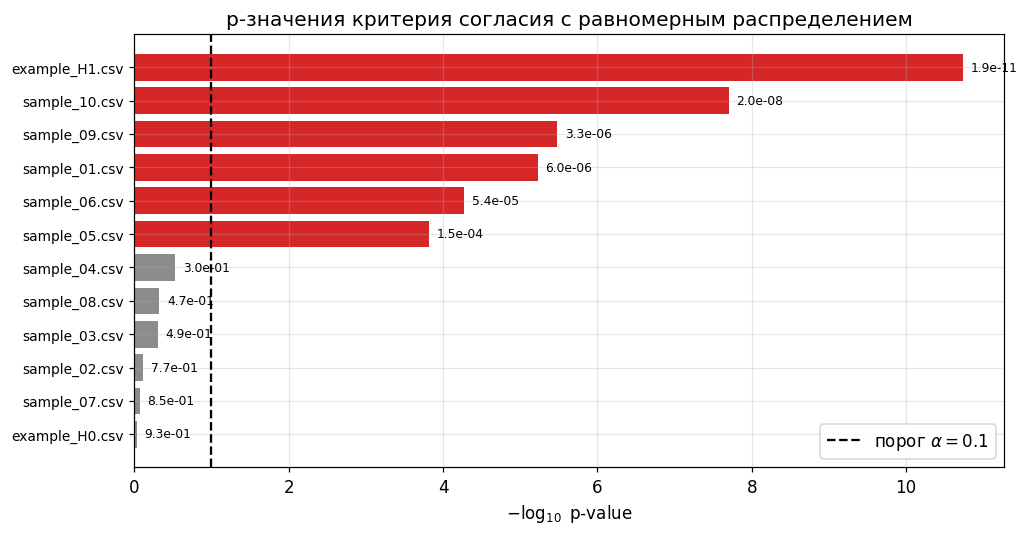

In [14]:
# 5.4. Сводная картина по всем 12 файлам
fig, ax = plt.subplots(figsize=(9.5, 5))
all_names = list(ALL)
pvals = np.array([ks_uniform(ALL[f])[1] for f in all_names])
order = np.argsort(-pvals)
colors = np.array(["tab:red" if p < ALPHA else "0.55" for p in pvals])
ax.barh(range(len(order)), -np.log10(pvals[order]), color=colors[order])
ax.set_yticks(range(len(order)))
ax.set_yticklabels([all_names[i] for i in order], fontsize=9)
ax.axvline(-np.log10(ALPHA), color="k", ls="--",
           label=rf"порог $\alpha={ALPHA}$")
ax.set_xlabel(r"$-\log_{10}$ p-value")
ax.set_title("p-значения критерия согласия с равномерным распределением")
for i, j in enumerate(order):
    ax.text(-np.log10(pvals[j]) + 0.1, i, f"{pvals[j]:.1e}", va="center", fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

## Отчёт по заданию (сводно)

**1. Описание эксперимента.** Угол продольного шва стеклянной бутылки
измеряется видеодатчиком перед захватом этикетировочной машины; этикетка
наклеивается на шов и морщится, отсюда брак. Бутылки не ориентированы, и если
механика их не доворачивает, углы должны быть равномерно распределены по всему
обороту.

**2. Гипотезы.** $H_0$: $F(x) = x/360$ на $[0,360)$ — выделенного положения
шва нет, виноваты клей и температура. $H_1$: распределение отличается от
равномерного — есть сектор, в который бутылки доворачиваются, виновата механика.

**3. Критерий.** Критерий согласия Колмогорова–Смирнова (№13) с равномерным
законом. Обоснование: гипотеза одновыборочная и о согласии с полностью
заданным распределением; выборка непрерывная (все значения различны), поэтому
критерии Хи-квадрат формально неприменимы; нормальность отвергнута
(Шапиро–Уилк №12, $p<10^{-3}$ на обоих файлах `D1`), поэтому критерии
Стьюдента и Уэлча неприменимы; распределения не связаны сдвигом, поэтому
ранговые критерии тоже неприменимы; проверка среднего (Стьюдента №1) на
контрпримерном распределении «фон + сектор 165…195°» отвергает $H_0$ ровно с
частотой $\alpha = 10\%$, то есть не имеет мощности. На `D1` критерий
откалиброван: $p = 0.93$ на `example_H0` (размер = номинал на симуляциях) и
$p = 1.8\cdot10^{-11}$ на `example_H1` (мощность $\approx 1$ при $n \ge 100$).

**4. Уровень значимости.** $\alpha = 0.10$: ложная тревога стоит получаса
работы механика и, по условию, ничего не портит, а пропуск дефекта — месяц
брака. Выводы устойчивы: при $\alpha = 0.05$ и $0.01$ решения не меняются.

**5. Результаты применения к `D2`.** $H_0$ отвергнута для линий
**sample_01, sample_05, sample_06, sample_09, sample_10**
($p \le 1.5\cdot10^{-4}$): у них есть выделенное положение шва, нужно
отрегулировать механику. $H_0$ не отвергнута для линий
**sample_02, sample_03, sample_04, sample_07, sample_08**
($p \ge 0.29$): данных за то, что доворачивает механика, нет, искать причину
брака надо в клее и температуре.

**Дополнительно (описательно).** У всех пяти отклонённых линий, как и у эталона
`example_H1`, перегружен один и тот же сектор **90°…120°**: 36–42 % бутылок на
каждой линии (43 % на эталоне `H1`) против 8.3 %, ожидаемых при равномерности.
Проблема одна и та же и общая для нескольких линий. KS на две выборки (№16)
подтверждает, что две группы линий статистически различаются
($D = 0.127$, $p = 3.2\cdot10^{-9}$).